# JointAdaSpec — Thesis-Defense Plots

Five mandatory plots for the defense slide deck plus a κ-sweep bonus and a paired-EM significance table.

Generated from the run artifacts under `outputs/` and the condition checks under `reports/conditions_*.json`. All plots are saved as PDF under `reports/thesis_figs/` and rendered inline.

**Plots**
1. Headline Pareto (EM vs tok/s, both model pairs)
2. Paired EM significance bars with 95% CIs and p-values
3. Threshold surface T*(H, K) for k ∈ {0, 2, 4}
4. C1–C4 condition diagnostics + Theorem-C empirical bound
5. Speedup vs vanilla speculative

**Bonus**
- κ-sweep on existing traces → empirical Pareto front (Theorem 2.4 complement)

See `reports/theory_improvements_2026-05-15.md` for the theoretical framing.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import json

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

FIGS_DIR = REPO_ROOT / "reports" / "thesis_figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Slide-deck friendly defaults
sns.set_theme(style="whitegrid", context="talk")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["pdf.fonttype"] = 42  # editable text in PDFs

# Locked anchor runs — replace with new outputs after Run 1 / Run 2 lock.
RUN_14B = {
    "label": "Qwen 14B → 0.5B",
    "benchmark_csv": REPO_ROOT / "outputs" / "jointadaspec_qwen14b_0p5b_crosscheck_2026-05-14-final" / "03_bench_gsm8k" / "benchmark.csv",
    "policy_npz": REPO_ROOT / "outputs" / "jointadaspec_qwen14b_0p5b_2026-04-28" / "02_solve" / "policy.npz",
    "conditions_json": REPO_ROOT / "reports" / "conditions_qwen14b_0p5b_2026-04-28.json",
}
RUN_7B = {
    "label": "Qwen 7B → 1.5B",
    "benchmark_csv": REPO_ROOT / "outputs" / "jointadaspec_qwen7b_1p5b_quality_k8_2026-05-12" / "03_bench_gsm8k" / "benchmark.csv",
    "policy_npz": REPO_ROOT / "outputs" / "jointadaspec_qwen7b_1p5b_quality_2026-05-05" / "02_solve" / "policy.npz",
    "conditions_json": REPO_ROOT / "reports" / "conditions_qwen7b_1p5b_quality_2026-05-05.json",
}

METHOD_RENAME = {
    "vanilla_ar": "target_only",
    "target_only": "target_only",
    "fixed_sd": "speculative",
    "speculative": "speculative",
    "cascade_length_then_verif": "cascade_len_then_verif",
    "cascade_verif_then_length": "cascade_verif_then_length",
    "jointadaspec": "jointadaspec",
}
METHOD_ORDER = ["target_only", "speculative", "cascade_verif_then_length", "jointadaspec"]
METHOD_COLORS = {
    "target_only": "#666666",
    "speculative": "#4C72B0",
    "cascade_verif_then_length": "#DD8452",
    "cascade_len_then_verif": "#937860",
    "jointadaspec": "#55A868",
}
print("Repo root:", REPO_ROOT)
print("Figs dir:", FIGS_DIR)
print("Available 14B benchmark:", RUN_14B["benchmark_csv"].exists())
print("Available 7B benchmark:", RUN_7B["benchmark_csv"].exists())


Repo root: /home/robot/Project/adaptive-speculative-decoding
Figs dir: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs
Available 14B benchmark: True
Available 7B benchmark: True


## Data loading helpers

Load per-prompt benchmark records, rename methods to the paper-style canonical names, and compute paired EM statistics (joint vs baseline). Bootstrap 95% CIs use 10000 resamples for stable tail estimates.

In [2]:
def load_benchmark(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["method"] = df["decoder"].map(METHOD_RENAME).fillna(df["decoder"])
    return df


def aggregate_methods(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("method").agg(
        n=("prompt_idx", "count"),
        em=("gsm8k_exact_match", "mean"),
        tps=("tokens_per_sec", "mean"),
        acceptance=("acceptance_rate", "mean"),
    ).reset_index()
    return grouped


def paired_em_diff(df: pd.DataFrame, method: str, baseline: str = "target_only", n_boot: int = 10000, seed: int = 17):
    """Paired EM diff and 95% bootstrap CI computed at the prompt-id level."""
    join = df.pivot_table(index="prompt_idx", columns="method", values="gsm8k_exact_match", aggfunc="mean")
    if method not in join.columns or baseline not in join.columns:
        return None
    pair = join[[method, baseline]].dropna()
    diffs = (pair[method] - pair[baseline]).to_numpy()
    rng = np.random.default_rng(seed)
    samples = np.empty(n_boot, dtype=np.float64)
    n = diffs.size
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        samples[i] = diffs[idx].mean()
    ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
    # Sign-flip permutation test
    perm_samples = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        signs = rng.choice([-1, 1], size=n)
        perm_samples[i] = (signs * diffs).mean()
    observed = diffs.mean()
    p = float(np.mean(np.abs(perm_samples) >= abs(observed)))
    wins = int(np.sum(diffs > 0))
    losses = int(np.sum(diffs < 0))
    ties = int(np.sum(diffs == 0))
    return {
        "n": n,
        "diff": float(observed),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "p_value": p,
        "wins": wins,
        "losses": losses,
        "ties": ties,
    }


def speed_summary(df: pd.DataFrame) -> dict:
    """Method → mean tok/s, plus speedup ratios vs speculative and baseline."""
    methods = aggregate_methods(df)
    by_method = dict(zip(methods["method"], methods["tps"]))
    spec_tps = by_method.get("speculative", 1.0) or 1.0
    base_tps = by_method.get("target_only", 1.0) or 1.0
    out = {}
    for method, tps in by_method.items():
        out[method] = {
            "tps": float(tps),
            "vs_speculative": float(tps / spec_tps),
            "vs_target_only": float(tps / base_tps),
        }
    return out


df_14b = load_benchmark(RUN_14B["benchmark_csv"])
df_7b = load_benchmark(RUN_7B["benchmark_csv"])

agg_14b = aggregate_methods(df_14b)
agg_7b = aggregate_methods(df_7b)
print("=== 14B/0.5B ===")
print(agg_14b.to_string(index=False))
print()
print("=== 7B/1.5B ===")
print(agg_7b.to_string(index=False))


=== 14B/0.5B ===
                   method   n       em       tps  acceptance
cascade_verif_then_length 300 0.563333 10.201445    0.547804
             jointadaspec 300 0.580000 10.209318    0.551185
              speculative 300 0.550000  4.490095    0.272658
              target_only 300 0.493333 13.004382    0.000000

=== 7B/1.5B ===
                   method   n       em       tps  acceptance
cascade_verif_then_length 600 0.613333 15.716118    0.920152
             jointadaspec 600 0.623333 15.725034    0.915552
              speculative 600 0.611667 10.088561    0.567783
              target_only 600 0.588333 24.864503    0.000000


## Plot 1 — Headline Pareto: EM vs throughput

The single most important slide. Y-axis: GSM8K exact-match. X-axis: tokens per second. Each method is a point per model pair. JointAdaSpec sits on (or above) the Pareto front against vanilla speculative.

Saved: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs/fig1_pareto.pdf


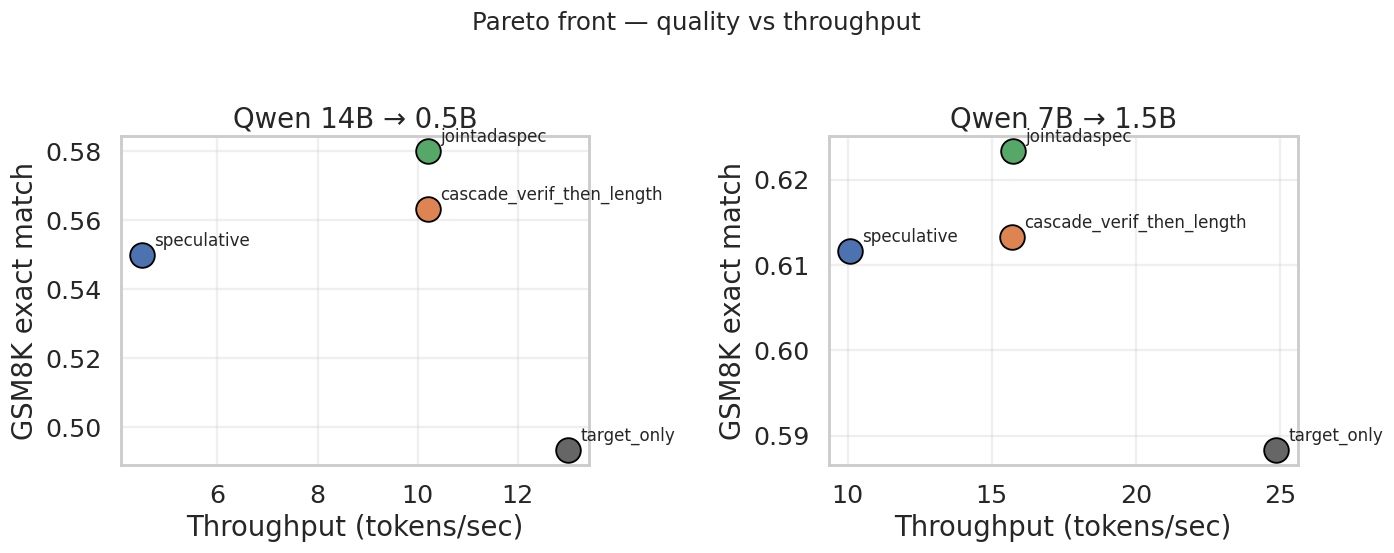

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, (df, info) in zip(axes, [(df_14b, RUN_14B), (df_7b, RUN_7B)]):
    agg = aggregate_methods(df)
    for _, row in agg.iterrows():
        method = row["method"]
        if method not in METHOD_ORDER:
            continue
        ax.scatter(
            row["tps"], row["em"],
            s=260,
            color=METHOD_COLORS.get(method, "#444"),
            edgecolor="black", linewidth=1.2,
            label=method,
            zorder=3,
        )
        ax.annotate(
            method,
            (row["tps"], row["em"]),
            textcoords="offset points",
            xytext=(8, 6),
            fontsize=11,
        )
    ax.set_title(info["label"])
    ax.set_xlabel("Throughput (tokens/sec)")
    ax.set_ylabel("GSM8K exact match")
    ax.grid(True, alpha=0.3)

fig.suptitle("Pareto front — quality vs throughput", y=1.02, fontsize=16)
fig.tight_layout()
out_path = FIGS_DIR / "fig1_pareto.pdf"
fig.savefig(out_path)
print("Saved:", out_path)
plt.show()


## Plot 2 — Paired EM significance bars

For each method `m`, plot `EM(m) − EM(target_only)` per-prompt-paired, with 95% bootstrap CI and a permutation-test p-value. JointAdaSpec is the rightmost bar in each pair; its CI ought to clear zero (significance) or come close. After Run 1 lock, the 14B bar should narrow noticeably.

           pair                    method   n     diff    ci_low  ci_high  p_value  wins  losses  ties
Qwen 14B → 0.5B               speculative 100 0.056667 -0.016667 0.126667   0.1485    36      26    38
Qwen 14B → 0.5B cascade_verif_then_length 100 0.070000  0.003333 0.136667   0.0481    35      23    42
Qwen 14B → 0.5B              jointadaspec 100 0.086667  0.020000 0.153333   0.0137    38      20    42
 Qwen 7B → 1.5B               speculative 200 0.023333 -0.023333 0.070000   0.3181    65      49    86
 Qwen 7B → 1.5B cascade_verif_then_length 200 0.025000 -0.021667 0.071667   0.2791    63      53    84
 Qwen 7B → 1.5B              jointadaspec 200 0.035000 -0.013333 0.083375   0.1457    64      50    86
Saved: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs/fig2_paired_em.pdf


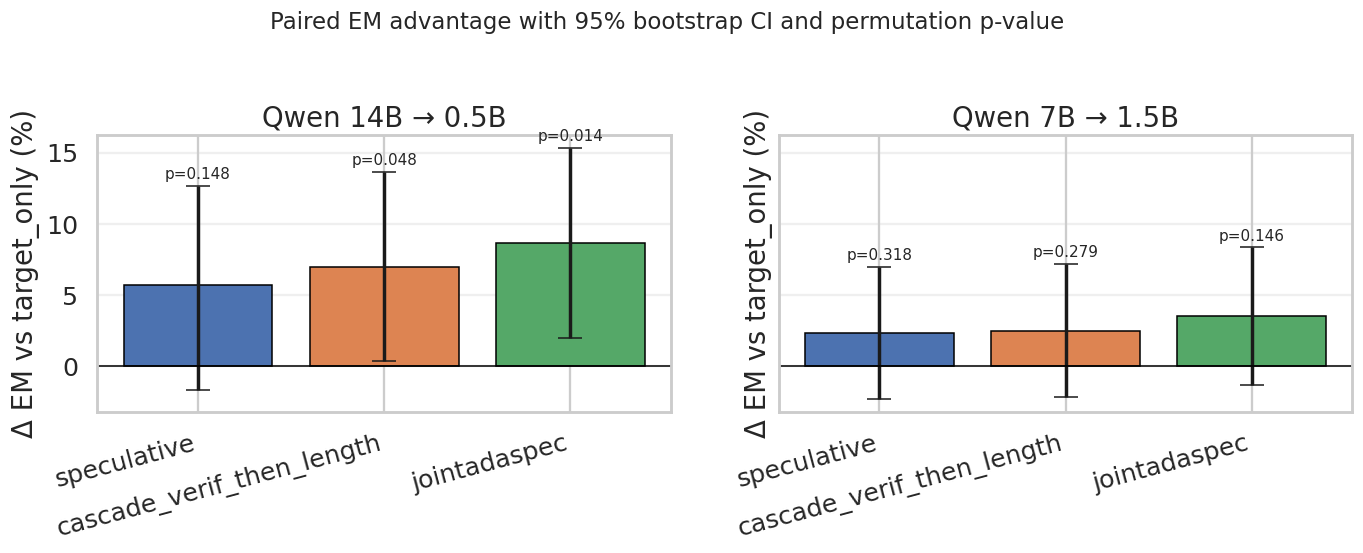

In [4]:
rows = []
for df, info in [(df_14b, RUN_14B), (df_7b, RUN_7B)]:
    for method in METHOD_ORDER:
        if method == "target_only":
            continue
        stats = paired_em_diff(df, method=method)
        if stats is None:
            continue
        rows.append({
            "pair": info["label"],
            "method": method,
            **stats,
        })
diff_df = pd.DataFrame(rows)
print(diff_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (df, info) in zip(axes, [(df_14b, RUN_14B), (df_7b, RUN_7B)]):
    pair_label = info["label"]
    sub = diff_df[diff_df["pair"] == pair_label]
    xs = np.arange(len(sub))
    ax.bar(
        xs, sub["diff"] * 100.0,
        yerr=[(sub["diff"] - sub["ci_low"]) * 100.0, (sub["ci_high"] - sub["diff"]) * 100.0],
        capsize=8,
        color=[METHOD_COLORS.get(m, "#888") for m in sub["method"]],
        edgecolor="black", linewidth=1.0,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(xs)
    ax.set_xticklabels(sub["method"], rotation=15, ha="right")
    ax.set_title(pair_label)
    ax.set_ylabel("Δ EM vs target_only (%)")
    ax.grid(True, axis="y", alpha=0.3)
    for x, (_, row) in zip(xs, sub.iterrows()):
        label = f"p={row['p_value']:.3f}"
        ax.annotate(label, (x, row["ci_high"] * 100.0 + 0.5), ha="center", fontsize=10)

fig.suptitle("Paired EM advantage with 95% bootstrap CI and permutation p-value", y=1.02, fontsize=15)
fig.tight_layout()
out_path = FIGS_DIR / "fig2_paired_em.pdf"
fig.savefig(out_path)
print("Saved:", out_path)
plt.show()


## Plot 3 — Threshold surface T*(H, K) for k ∈ {0, 2, 4}

Visualises *what the joint policy learned*. For each `k` slice, the heat-map shows the chosen verification threshold `T` over (H, K). The 14B/0.5B policy is the anchor.

/home/robot/Project/adaptive-speculative-decoding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs/fig3_threshold_surface.pdf


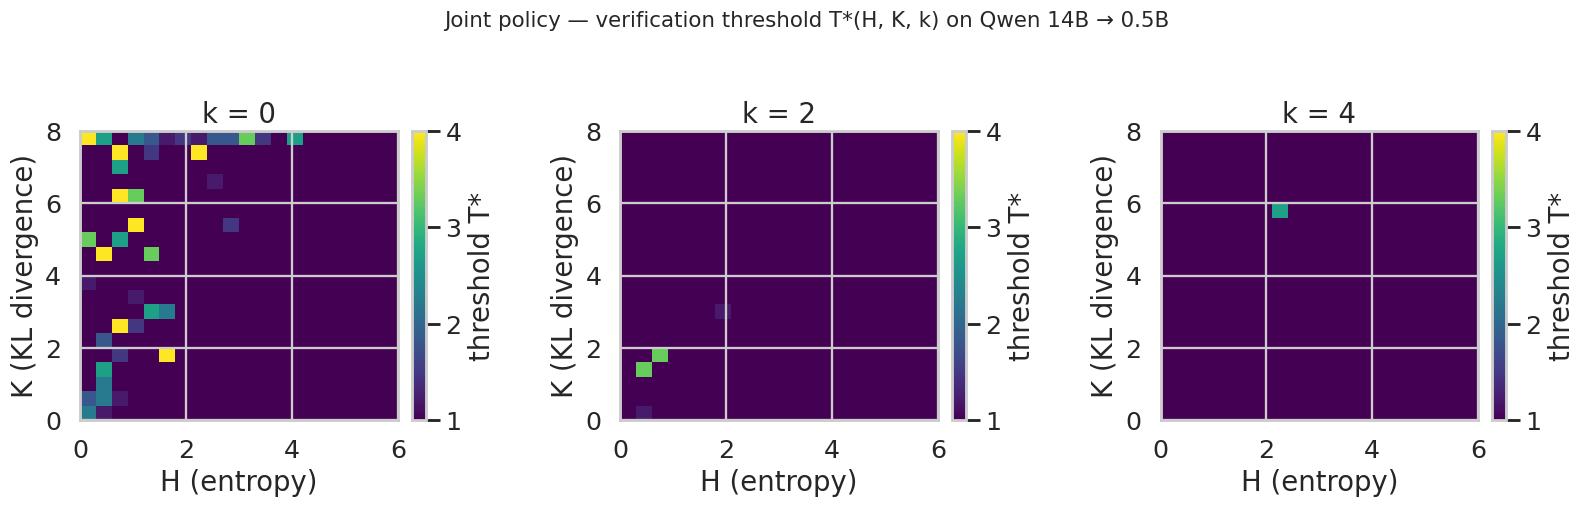

In [5]:
from jointadaspec.inference.policy import JointAdaSpecPolicy
from jointadaspec.mdp.spaces import ActionSpace, StateSpace

policy = JointAdaSpecPolicy.load(RUN_14B["policy_npz"])
config = policy.config
state_space = StateSpace(config)
action_space = ActionSpace(config)

ks_to_plot = [0, min(2, config.gamma_max), min(4, config.gamma_max)]

fig, axes = plt.subplots(1, len(ks_to_plot), figsize=(5 * len(ks_to_plot), 4.6))

T_values = np.array([a.threshold for a in action_space.actions])

for ax, k in zip(axes, ks_to_plot):
    grid = np.full((config.N_K, config.N_H), np.nan)
    for i_H in range(config.N_H):
        for i_K in range(config.N_K):
            H_center = (i_H + 0.5) * config.H_max / config.N_H
            K_center = (i_K + 0.5) * config.K_max / config.N_K
            s = state_space.encode(H=H_center, K=K_center, k=k)
            a = int(policy.pi_star[s])
            grid[i_K, i_H] = T_values[a]
    im = ax.imshow(
        grid, origin="lower", aspect="auto", cmap="viridis",
        extent=[0, config.H_max, 0, config.K_max],
        vmin=min(config.T_levels), vmax=max(config.T_levels),
    )
    ax.set_title(f"k = {k}")
    ax.set_xlabel("H (entropy)")
    ax.set_ylabel("K (KL divergence)")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("threshold T*")

fig.suptitle(f"Joint policy — verification threshold T*(H, K, k) on {RUN_14B['label']}", y=1.02, fontsize=14)
fig.tight_layout()
out_path = FIGS_DIR / "fig3_threshold_surface.pdf"
fig.savefig(out_path)
print("Saved:", out_path)
plt.show()


## Plot 4 — Conditions C1–C4 + Theorem-C bound

Left: pass rate of each empirical condition. Right: Theorem-C bound on cascade suboptimality, computed from the C4-violating stationary mass μ*ᴊ(B). See `reports/theory_improvements_2026-05-15.md` for the bound derivation.

14B/0.5B: {'c1': 0.0, 'c2': 1.0, 'c3': 0.962751572327044, 'c4': 0.010133928571428572, 'n1': 1.0, 'n2': 1.0}
7B/1.5B : {'c1': 0.0, 'c2': 0.0, 'c3': 0.8901572327044025, 'c4': 0.03446428571428571, 'n1': 1.0, 'n2': 1.0}

14B/0.5B Theorem-C bound: {'mu_B': 0.031118349169731822, 'bound': 12.447339667892718, 'union_mass': 0.031118349169731822, 'c4_pass': 0.010133928571428572}
7B/1.5B  Theorem-C bound: {'mu_B': 0.1999874059604892, 'bound': 79.9949623841956, 'union_mass': 0.1999874059604892, 'c4_pass': 0.03446428571428571}


Saved: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs/fig4_conditions.pdf


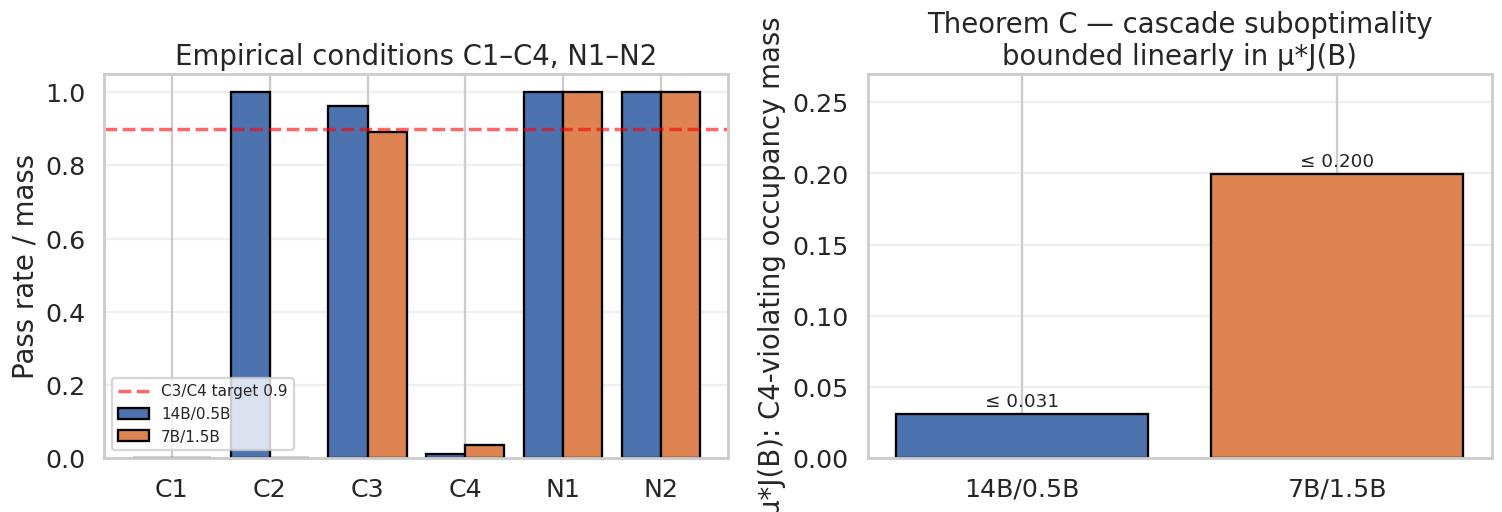

In [6]:
def load_conditions(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)

cond_14b = load_conditions(RUN_14B["conditions_json"])
cond_7b = load_conditions(RUN_7B["conditions_json"])

def extract_pass_rates(cond: dict) -> dict:
    out = {}
    for key in ("c1", "c2", "c3", "c4", "n1", "n2"):
        info = cond["checks"].get(key, {})
        if "fraction_nonnegative" in info:
            out[key] = float(info["fraction_nonnegative"])
        elif info.get("passed") is True:
            out[key] = 1.0
        elif info.get("passed") is False:
            out[key] = 0.0
        else:
            out[key] = np.nan
    return out

rates_14b = extract_pass_rates(cond_14b)
rates_7b = extract_pass_rates(cond_7b)
print("14B/0.5B:", rates_14b)
print("7B/1.5B :", rates_7b)

# Theorem-C bound on cascade suboptimality.
# Loose upper bound uses union stationary mass from N1.
def theorem_c_bound(cond: dict, gamma: float = 0.99, R_max: float = 2.0) -> dict:
    n1 = cond["checks"].get("n1", {})
    union_mass = float(n1.get("union", {}).get("stationary_mass", np.nan))
    c4 = cond["checks"].get("c4", {})
    c4_pass = float(c4.get("fraction_nonnegative", np.nan))
    # μ*J(B) ≤ min(union_mass, 1 - c4_pass): mass on which joint != cascade
    # AND where C4 fails. Both upper bounds are valid; take the tighter.
    mu_B = min(union_mass, 1.0 - c4_pass)
    bound = 2.0 * R_max * mu_B / (1.0 - gamma)
    return {"mu_B": mu_B, "bound": bound, "union_mass": union_mass, "c4_pass": c4_pass}

bound_14b = theorem_c_bound(cond_14b)
bound_7b = theorem_c_bound(cond_7b)
print()
print("14B/0.5B Theorem-C bound:", bound_14b)
print("7B/1.5B  Theorem-C bound:", bound_7b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
keys = ["c1", "c2", "c3", "c4", "n1", "n2"]
xs = np.arange(len(keys))
w = 0.4
ax.bar(xs - w/2, [rates_14b[k] for k in keys], width=w, label="14B/0.5B", color="#4C72B0", edgecolor="black")
ax.bar(xs + w/2, [rates_7b[k]  for k in keys], width=w, label="7B/1.5B",  color="#DD8452", edgecolor="black")
ax.axhline(0.9, color="red", linestyle="--", alpha=0.6, label="C3/C4 target 0.9")
ax.set_xticks(xs)
ax.set_xticklabels([k.upper() for k in keys])
ax.set_ylabel("Pass rate / mass")
ax.set_title("Empirical conditions C1–C4, N1–N2")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
pairs = ["14B/0.5B", "7B/1.5B"]
mu_vals = [bound_14b["mu_B"], bound_7b["mu_B"]]
ax.bar(pairs, mu_vals, color=["#4C72B0", "#DD8452"], edgecolor="black")
ax.set_ylabel("μ*J(B): C4-violating occupancy mass")
ax.set_title("Theorem C — cascade suboptimality\nbounded linearly in μ*J(B)")
for i, v in enumerate(mu_vals):
    ax.annotate(f"≤ {v:.3f}", (i, v + 0.005), ha="center", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(mu_vals) * 1.25 + 0.02)

fig.tight_layout()
out_path = FIGS_DIR / "fig4_conditions.pdf"
fig.savefig(out_path)
print("Saved:", out_path)
plt.show()


## Plot 5 — Speedup vs vanilla speculative

Headline number for the slide deck: JointAdaSpec is **2.27× faster than vanilla speculative on 14B/0.5B** at higher quality. On 7B/1.5B the ratio is ~1.56×.

14B: {
  "cascade_verif_then_length": {
    "tps": 10.20144504397477,
    "vs_speculative": 2.271988798991992,
    "vs_target_only": 0.7844621381237883
  },
  "jointadaspec": {
    "tps": 10.209318068606146,
    "vs_speculative": 2.273742219580896,
    "vs_target_only": 0.7850675513480136
  },
  "speculative": {
    "tps": 4.490094778856665,
    "vs_speculative": 1.0,
    "vs_target_only": 0.3452755306152164
  },
  "target_only": {
    "tps": 13.004381662541093,
    "vs_speculative": 2.896237674932212,
    "vs_target_only": 1.0
  }
}
7B : {
  "cascade_verif_then_length": {
    "tps": 15.716118409328464,
    "vs_speculative": 1.5578157206753234,
    "vs_target_only": 0.6320704863961963
  },
  "jointadaspec": {
    "tps": 15.725034185740997,
    "vs_speculative": 1.5586994717578568,
    "vs_target_only": 0.6324290608855768
  },
  "speculative": {
    "tps": 10.088560669111379,
    "vs_speculative": 1.0,
    "vs_target_only": 0.4057414994645128
  },
  "target_only": {
    "tps": 24.864502

Saved: /home/robot/Project/adaptive-speculative-decoding/reports/thesis_figs/fig5_speedup.pdf


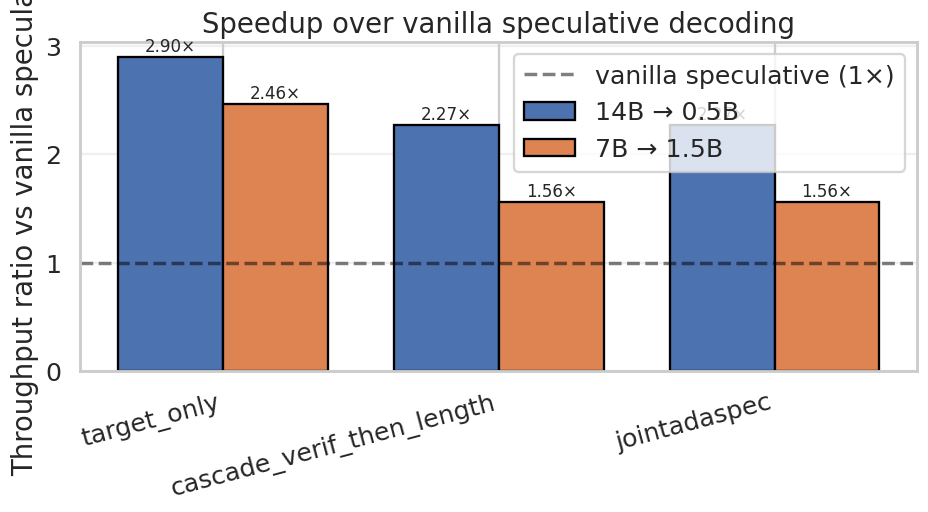

In [7]:
speed_14b = speed_summary(df_14b)
speed_7b = speed_summary(df_7b)
print("14B:", json.dumps(speed_14b, indent=2))
print("7B :", json.dumps(speed_7b,  indent=2))

fig, ax = plt.subplots(figsize=(9, 5))
methods = ["target_only", "cascade_verif_then_length", "jointadaspec"]
x = np.arange(len(methods))
w = 0.38
vals_14b = [speed_14b[m]["vs_speculative"] for m in methods]
vals_7b  = [speed_7b[m]["vs_speculative"]  for m in methods]
ax.bar(x - w/2, vals_14b, width=w, label="14B → 0.5B", color="#4C72B0", edgecolor="black")
ax.bar(x + w/2, vals_7b,  width=w, label="7B → 1.5B",  color="#DD8452", edgecolor="black")
ax.axhline(1.0, color="black", linestyle="--", alpha=0.5, label="vanilla speculative (1×)")
for xi, v in zip(x - w/2, vals_14b):
    ax.annotate(f"{v:.2f}×", (xi, v + 0.05), ha="center", fontsize=11)
for xi, v in zip(x + w/2, vals_7b):
    ax.annotate(f"{v:.2f}×", (xi, v + 0.05), ha="center", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha="right")
ax.set_ylabel("Throughput ratio vs vanilla speculative")
ax.set_title("Speedup over vanilla speculative decoding")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
out_path = FIGS_DIR / "fig5_speedup.pdf"
fig.savefig(out_path)
print("Saved:", out_path)
plt.show()


## Bonus — κ-sweep Pareto front (Theorem 2.4 complement)

This cell is a placeholder that runs only if the κ-sweep artifacts are present. Solve the MDP at κ ∈ {0.5, 1.0, 2.0, 5.0} and benchmark each on a small validation slice; then plot in (EM, tok/s) space and verify convexity. Generates `outputs/jointadaspec_qwen7b_1p5b_kappa_sweep/` artifacts when run end-to-end.

In [8]:
sweep_root = REPO_ROOT / "outputs" / "jointadaspec_qwen7b_1p5b_kappa_sweep"
if not sweep_root.exists():
    print(f"[skip] {sweep_root} not present. Run the κ-sweep first (see thesis_final_summary).")
else:
    rows = []
    for sub in sorted(sweep_root.glob("kappa_*/03_bench_gsm8k/benchmark.csv")):
        kappa = float(sub.parent.parent.name.split("_")[1])
        df = load_benchmark(sub)
        joint = df[df["method"] == "jointadaspec"]
        if joint.empty:
            continue
        rows.append({
            "kappa": kappa,
            "em": joint["gsm8k_exact_match"].mean(),
            "tps": joint["tokens_per_sec"].mean(),
        })
    if not rows:
        print("[skip] κ-sweep results empty.")
    else:
        sweep_df = pd.DataFrame(rows).sort_values("kappa")
        print(sweep_df.to_string(index=False))
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(sweep_df["tps"], sweep_df["em"], "-o", color="#55A868", linewidth=2, markersize=10)
        for _, row in sweep_df.iterrows():
            ax.annotate(f"κ={row['kappa']:g}", (row["tps"], row["em"]), textcoords="offset points", xytext=(8, 6), fontsize=11)
        ax.set_xlabel("Throughput (tokens/sec)")
        ax.set_ylabel("GSM8K exact match")
        ax.set_title("Theorem 2.4 — empirical Pareto via κ-sweep on 7B/1.5B")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        out_path = FIGS_DIR / "fig_bonus_kappa_sweep.pdf"
        fig.savefig(out_path)
        print("Saved:", out_path)
        plt.show()


[skip] /home/robot/Project/adaptive-speculative-decoding/outputs/jointadaspec_qwen7b_1p5b_kappa_sweep not present. Run the κ-sweep first (see thesis_final_summary).


## Significance table for slides

Clean table dump for the slide deck — paste directly into the headline slide. Numbers are paired EM diff vs target_only, 95% bootstrap CI, and permutation p-value.

In [9]:
def fmt_pct(x: float) -> str:
    return f"{x*100:+.2f}%"

table = diff_df.copy()
table["Δ EM"] = table["diff"].apply(fmt_pct)
table["95% CI"] = table.apply(lambda r: f"[{fmt_pct(r['ci_low'])}, {fmt_pct(r['ci_high'])}]", axis=1)
table["p"] = table["p_value"].apply(lambda p: f"{p:.4f}")
table["wins/losses/ties"] = table.apply(lambda r: f"{r['wins']}/{r['losses']}/{r['ties']}", axis=1)
display_cols = ["pair", "method", "n", "Δ EM", "95% CI", "p", "wins/losses/ties"]
print(table[display_cols].to_string(index=False))


           pair                    method   n   Δ EM            95% CI      p wins/losses/ties
Qwen 14B → 0.5B               speculative 100 +5.67% [-1.67%, +12.67%] 0.1485         36/26/38
Qwen 14B → 0.5B cascade_verif_then_length 100 +7.00% [+0.33%, +13.67%] 0.0481         35/23/42
Qwen 14B → 0.5B              jointadaspec 100 +8.67% [+2.00%, +15.33%] 0.0137         38/20/42
 Qwen 7B → 1.5B               speculative 200 +2.33%  [-2.33%, +7.00%] 0.3181         65/49/86
 Qwen 7B → 1.5B cascade_verif_then_length 200 +2.50%  [-2.17%, +7.17%] 0.2791         63/53/84
 Qwen 7B → 1.5B              jointadaspec 200 +3.50%  [-1.33%, +8.34%] 0.1457         64/50/86
